In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
df = pd.read_csv("zillow_cleaned.csv")

# Drop rows with missing target
df = df.dropna(subset=["taxvaluedollarcnt"]).copy()

# Define target and features
y = df["taxvaluedollarcnt"]
X = df[["calculatedfinishedsquarefeet", "bedroomcnt", "bathroomcnt", "lotsizesquarefeet", "yearbuilt"]]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [2]:
# Create polynomial and interaction terms up to degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Check how many features we now have
print(f"Original features: {X_train.shape[1]}")
print(f"After polynomial expansion: {X_train_poly.shape[1]}")

Original features: 5
After polynomial expansion: 20


In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

In [4]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)
r2_linear = r2_score(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))

print(f"Linear Regression R²: {r2_linear:.3f}")
print(f"Linear Regression RMSE: {rmse_linear:.0f}")

Linear Regression R²: 0.376
Linear Regression RMSE: 330646


In [5]:
poly_model = LinearRegression()
poly_model.fit(X_train_scaled, y_train)

y_pred_poly = poly_model.predict(X_test_scaled)
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print(f"Polynomial Regression R²: {r2_poly:.3f}")
print(f"Polynomial Regression RMSE: {rmse_poly:.0f}")

Polynomial Regression R²: 0.389
Polynomial Regression RMSE: 327204


In [6]:
ridge_model = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Ridge (Poly) Regression R²: {r2_ridge:.3f}")
print(f"Ridge (Poly) Regression RMSE: {rmse_ridge:.0f}")
print(f"Best alpha: {ridge_model.alpha_}")

Ridge (Poly) Regression R²: 0.389
Ridge (Poly) Regression RMSE: 327180
Best alpha: 0.1


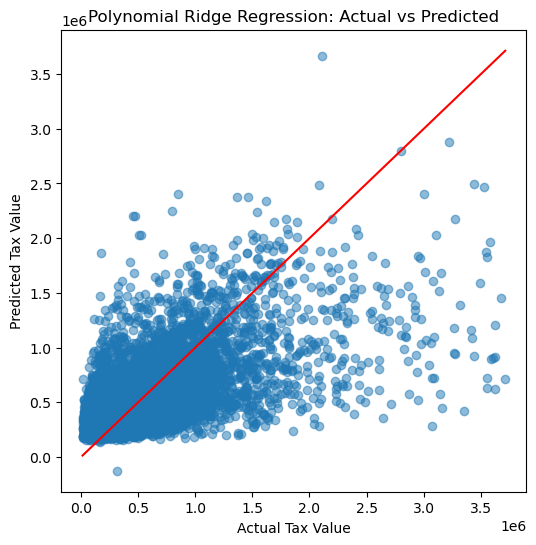

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual Tax Value")
plt.ylabel("Predicted Tax Value")
plt.title("Polynomial Ridge Regression: Actual vs Predicted")
plt.show()

### Week 1: Polynomial and Interaction Terms

In this step, I explored polynomial and interaction features to model non-linear relationships between housing characteristics and tax value.

After applying `PolynomialFeatures(degree=2)` to five numeric predictors (`squarefeet`, `bedrooms`, `bathrooms`, `lot size`, and `year built`), the feature count expanded from **5 to 20**. This allowed the model to consider second-order effects and pairwise interactions.

**Results Summary:**

| Model | R² | RMSE |
|--------|----|------|
| Linear Regression | 0.376 | 330,646 |
| Polynomial Regression | 0.389 | 327,204 |
| Ridge (Polynomial) Regression | 0.389 | 327,180 |

Adding polynomial and interaction terms modestly improved model fit, confirming that non-linear patterns exist in the data. The regularized Ridge model provided the best bias–variance balance with `alpha=0.1`.

The **Actual vs Predicted** plot shows reasonable alignment for most homes, with some underestimation for higher-value properties.

**Key Takeaways:**
- Polynomial terms capture subtle non-linear trends.
- Regularization (Ridge) helps prevent overfitting as feature count increases.
- Degree=2 offered the best trade-off between complexity and performance.

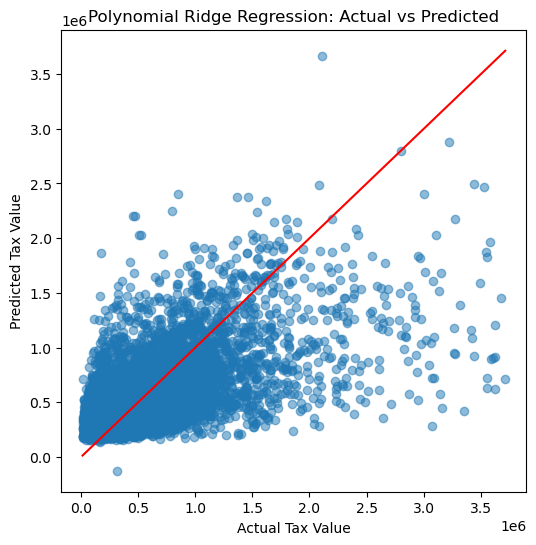

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual Tax Value")
plt.ylabel("Predicted Tax Value")
plt.title("Polynomial Ridge Regression: Actual vs Predicted")

plt.savefig("visuals/week1/poly_ridge_actual_vs_pred.png", dpi=200, bbox_inches="tight")
plt.show()

In [10]:

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Define preprocessor directly here
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, selector(dtype_include=np.number))
])

# Ridge Regression model with preprocessing
ridge_cv = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

# 5-fold CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = cross_val_score(ridge_cv, X_train, y_train, cv=cv, scoring="r2")

print(f"Week 1 — Ridge Regression 5-Fold CV R² Scores: {np.round(cv_r2_scores, 3)}")
print(f"Mean CV R²: {cv_r2_scores.mean():.3f} ± {cv_r2_scores.std():.3f}")

Week 1 — Ridge Regression 5-Fold CV R² Scores: [0.393 0.389 0.39  0.392 0.387]
Mean CV R²: 0.390 ± 0.002
